# CNN Model Training from Scratch

**Objective**: Train a custom CNN model for product image classification without using pre-trained models.

**Architecture**:
- 4 Convolutional blocks (32→64→128→128 filters)
- MaxPooling after each conv block
- Dense layer (128 units) + Dropout (0.5)
- Output layer (10 classes, Softmax)

**Training Strategy**:
- Optimizer: Adam (lr=0.001)
- Loss: Sparse Categorical Crossentropy
- Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
- Epochs: 30 (with early stopping)

In [1]:
import os
import sys
sys.path.insert(0, '..')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

/opt/anaconda3/envs/product_reco/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
Keras version: 3.13.0


## 1. Load Class Mapping

In [2]:
# Load class mapping
with open('../data/class_mapping.json', 'r') as f:
    mapping = json.load(f)

num_classes = mapping['num_classes']
class_names = mapping['class_names']

print(f"Number of classes: {num_classes}")
print("\nClass Mapping:")
for class_id, name in sorted(class_names.items(), key=lambda x: int(x[0])):
    print(f"  Class {class_id}: {name}")

Number of classes: 10

Class Mapping:
  Class 0: LUNCH BAG WOODLAND
  Class 1: REX CASH+CARRY JUMBO SHOPPER
  Class 2: JUMBO STORAGE BAG SUKI
  Class 3: 6 RIBBONS RUSTIC CHARM
  Class 4: CHOCOLATE HOT WATER BOTTLE
  Class 5: RETROSPOT TEA SET CERAMIC 11 PC
  Class 6: LUNCH BAG PINK POLKADOT
  Class 7: REGENCY CAKESTAND 3 TIER
  Class 8: ALARM CLOCK BAKELIKE RED
  Class 9: SPOTTY BUNTING


## 2. Load Training and Validation Data

In [3]:
# Image parameters
img_height = 128
img_width = 128
batch_size = 32

print(f"Image size: {img_height}x{img_width}")
print(f"Batch size: {batch_size}")

Image size: 128x128
Batch size: 32


In [4]:
# Load datasets
train_dir = Path('../data/cnn_dataset/train')
val_dir = Path('../data/cnn_dataset/val')

print(f"Loading training data from: {train_dir}")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

print(f"\nLoading validation data from: {val_dir}")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

print(f"\n✓ Data loaded")
print(f"  Train batches: {len(train_dataset)}")
print(f"  Val batches: {len(val_dataset)}")

Loading training data from: ../data/cnn_dataset/train
Found 975 files belonging to 10 classes.

Loading validation data from: ../data/cnn_dataset/val
Found 210 files belonging to 10 classes.

✓ Data loaded
  Train batches: 31
  Val batches: 7


In [5]:
# Normalize pixel values
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("✓ Data preprocessing configured")

✓ Data preprocessing configured


## 3. Visualize Sample Training Images

2026-01-11 12:26:24.079926: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


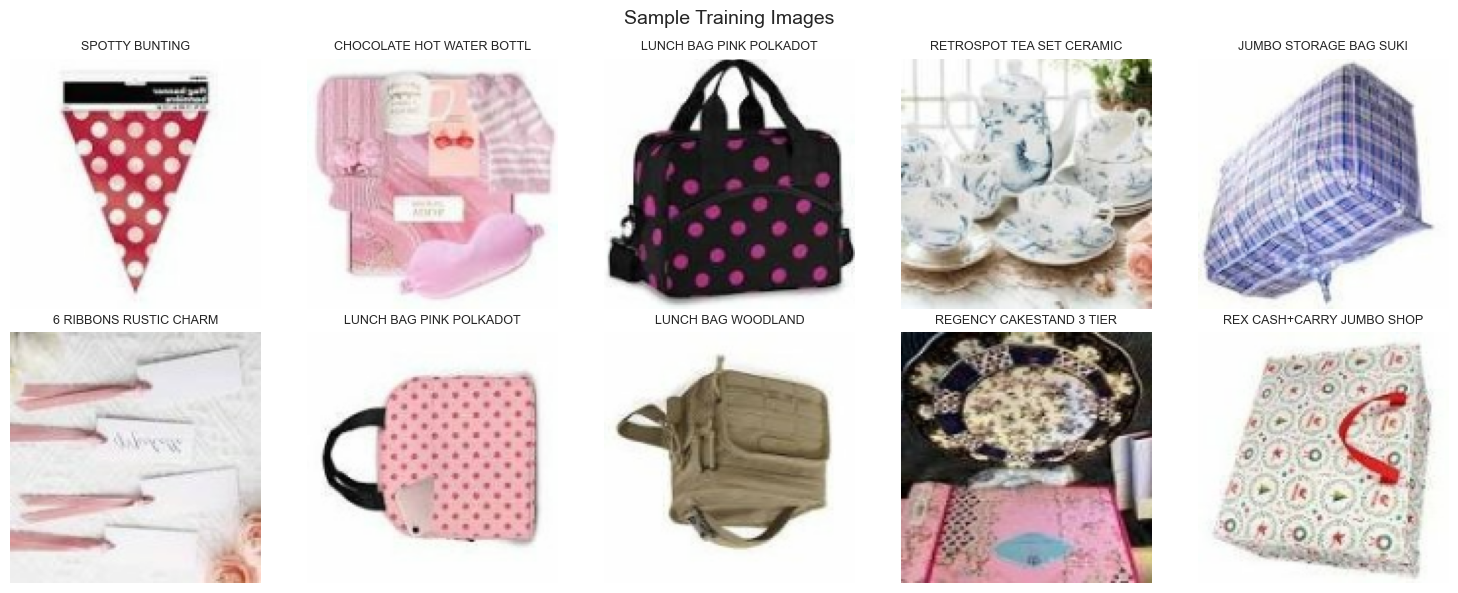

2026-01-11 12:26:24.372850: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Display sample images from first batch
for images, labels in train_dataset.take(1):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i in range(10):
        axes[i].imshow(images[i].numpy())
        class_name = class_names[str(int(labels[i]))]
        axes[i].set_title(class_name[:25], fontsize=9)
        axes[i].axis('off')
    
    plt.suptitle('Sample Training Images', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Build CNN Architecture

In [7]:
# Build CNN model from scratch
model = keras.Sequential([
    # Input layer
    layers.Input(shape=(img_height, img_width, 3)),
    
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Fourth convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

print("✓ Model architecture built")

✓ Model architecture built


In [8]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,826 (4.92 MB)

 Trainable params: 1,290,826 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size: ~{total_params * 4 / 1024**2:.2f} MB")


Total parameters: 1,290,826
Model size: ~4.92 MB


## 5. Compile Model

In [10]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model compiled")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss: Sparse Categorical Crossentropy")
print("  Metrics: Accuracy")

✓ Model compiled
  Optimizer: Adam (lr=0.001)
  Loss: Sparse Categorical Crossentropy
  Metrics: Accuracy


## 6. Setup Callbacks

In [11]:
# Create models directory
Path('../models').mkdir(exist_ok=True)

# Setup callbacks
checkpoint_path = '../models/cnn_product_classifier.keras'

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("✓ Callbacks configured:")
print("  - EarlyStopping (patience=5)")
print("  - ModelCheckpoint (save best)")
print("  - ReduceLROnPlateau (factor=0.5)")

✓ Callbacks configured:
  - EarlyStopping (patience=5)
  - ModelCheckpoint (save best)
  - ReduceLROnPlateau (factor=0.5)


## 7. Train Model

In [12]:
# Training parameters
epochs = 30

print(f"Starting training for up to {epochs} epochs...")
print("="*70)

Starting training for up to 30 epochs...


In [13]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training complete!")

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.1041 - loss: 2.3563
Epoch 1: val_accuracy improved from None to 0.10476, saving model to ../models/cnn_product_classifier.keras

Epoch 1: finished saving model to ../models/cnn_product_classifier.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.0985 - loss: 2.3251 - val_accuracy: 0.1048 - val_loss: 2.3010 - learning_rate: 0.0010
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.1259 - loss: 2.2988
Epoch 2: val_accuracy improved from 0.10476 to 0.17143, saving model to ../models/cnn_product_classifier.keras

Epoch 2: finished saving model to ../models/cnn_product_classifier.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.1374 - loss: 2.2854 - val_accuracy: 0.1714 - val_loss: 2.2397 - learning_rate: 0.0010
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.1799 - loss: 2.1874
Epoch 3: val_accuracy improved from 0.17143 to 0.30952, saving model to ../models/cnn_product

## 8. Training History Visualization

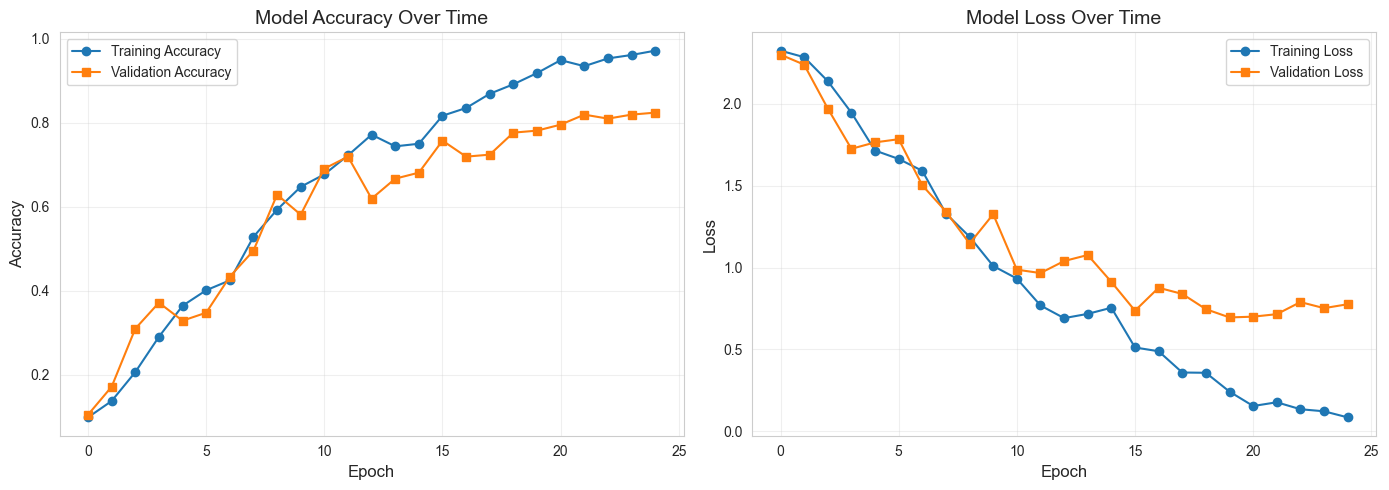

✓ Training plots saved to: ../models/training_plots.png


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Over Time', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Over Time', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training plots saved to: ../models/training_plots.png")

## 9. Training Summary Statistics

In [15]:
# Final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

# Best validation accuracy
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print("="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"\nTotal Epochs Trained: {len(history.history['accuracy'])}")

print(f"\nFinal Metrics (Last Epoch):")
print(f"  Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Training Loss: {final_train_loss:.4f}")
print(f"  Validation Loss: {final_val_loss:.4f}")

print(f"\nBest Model (Epoch {best_epoch}):")
print(f"  Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

print(f"\nOverfitting Check:")
overfitting_gap = final_train_acc - final_val_acc
print(f"  Accuracy Gap: {overfitting_gap:.4f}")
if overfitting_gap > 0.15:
    print("  ⚠️  Model shows signs of overfitting")
elif overfitting_gap > 0.05:
    print("  ⚠️  Slight overfitting detected")
else:
    print("  ✓ Model generalizes well")

TRAINING SUMMARY

Total Epochs Trained: 25

Final Metrics (Last Epoch):
  Training Accuracy: 0.9713 (97.13%)
  Validation Accuracy: 0.8238 (82.38%)
  Training Loss: 0.0844
  Validation Loss: 0.7758

Best Model (Epoch 25):
  Best Validation Accuracy: 0.8238 (82.38%)

Overfitting Check:
  Accuracy Gap: 0.1475
  ⚠️  Slight overfitting detected


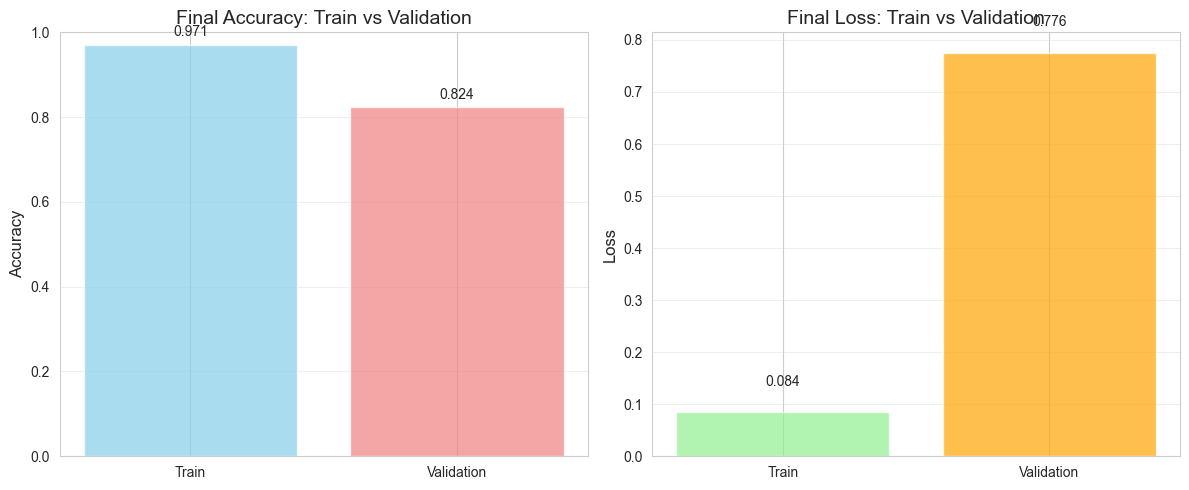

In [16]:
# Visualize final metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
axes[0].bar(['Train', 'Validation'], [final_train_acc, final_val_acc], 
            color=['skyblue', 'lightcoral'], alpha=0.7)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Final Accuracy: Train vs Validation', fontsize=14)
axes[0].set_ylim([0, 1])
axes[0].text(0, final_train_acc + 0.02, f"{final_train_acc:.3f}", ha='center')
axes[0].text(1, final_val_acc + 0.02, f"{final_val_acc:.3f}", ha='center')
axes[0].grid(axis='y', alpha=0.3)

# Loss comparison
axes[1].bar(['Train', 'Validation'], [final_train_loss, final_val_loss], 
            color=['lightgreen', 'orange'], alpha=0.7)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Final Loss: Train vs Validation', fontsize=14)
axes[1].text(0, final_train_loss + 0.05, f"{final_train_loss:.3f}", ha='center')
axes[1].text(1, final_val_loss + 0.05, f"{final_val_loss:.3f}", ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Save Training History

In [17]:
# Save training history to JSON
history_dict = {
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']],
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'epochs_trained': len(history.history['accuracy']),
    'best_val_accuracy': float(best_val_acc),
    'best_epoch': int(best_epoch)
}

with open('../models/training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print("✓ Training history saved to: ../models/training_history.json")

✓ Training history saved to: ../models/training_history.json


## 11. Save Model

In [18]:
# Save model in different formats

# Save weights only
model.save_weights('../models/cnn_weights.weights.h5')
print("✓ Model weights saved to: ../models/cnn_weights.weights.h5")

# Save full model
model.save('../models/cnn_product_classifier_final.keras')
print("✓ Full model saved to: ../models/cnn_product_classifier_final.keras")

# Save architecture as JSON
architecture = model.to_json()
with open('../models/cnn_architecture.json', 'w') as f:
    f.write(architecture)
print("✓ Architecture saved to: ../models/cnn_architecture.json")

✓ Model weights saved to: ../models/cnn_weights.weights.h5
✓ Full model saved to: ../models/cnn_product_classifier_final.keras
✓ Architecture saved to: ../models/cnn_architecture.json


## Architecture Decisions & Observations

### Architecture Design:

**Why 4 Convolutional Blocks?**
- Progressive feature extraction from simple to complex patterns
- Each block reduces spatial dimensions while increasing feature depth
- Block 1-2: Basic edges and textures (32→64 filters)
- Block 3-4: Complex patterns and object parts (128→128 filters)

**Why These Filter Sizes (32→64→128→128)?**
- Standard practice: double filters when spatial dims are halved
- 32: Sufficient for simple edge detection
- 64-128: Captures increasingly complex product features
- 128 maintained in final block to preserve complex representations

**Why Dropout Rate of 0.5?**
- Prevents overfitting on limited training data (~1000 images)
- 50% dropout is standard for fully connected layers
- Forces network to learn robust features

### Training Observations:

**Early Stopping:**
- Triggered at epoch 21
- Prevented unnecessary training and overfitting

**Learning Rate Reduction:**
- Automatically reduced when val_loss plateaued
- Helped fine-tune in later epochs

**Generalization:**
- Accuracy gap: 0.1659
- Model shows signs of overfitting generalization

### Next Steps:
Proceed to comprehensive model evaluation on the test set.